# THDMI Effect Size Comparison: Pre vs Post Case-Control Matching
## SAMPLE-SIZE CONTROLLED VERSION

This notebook provides a **fair comparison** of effect sizes before and after CCM by:

1. **Subsampling pre-CCM** to match post-CCM sample sizes (random subsampling)
2. **Bootstrap iterations** to get confidence intervals for pre-CCM effect sizes
3. **Proper statistical testing** comparing distributions of effect sizes

**THDMI Dataset Characteristics:**
- Cases (unhealthy=True): 1,058 samples (53.5%)
- Controls (unhealthy=False): 918 samples (46.5%)
- Ratio: 1.15:1 (nearly balanced, unlike AGP's extreme 1:27.6 imbalance)

The `unhealthy` column is a composite health indicator capturing:
- Diabetes, cardiovascular disease, IBS, obesity, mental illness, cancer, autoimmune, thyroid, lung disease

## 1. Setup and Imports

In [1]:
# Core imports
import pandas as pd
import numpy as np
import warnings
import os
import biom
warnings.filterwarnings('ignore')

# QIIME2 imports
from qiime2 import Artifact, Metadata
from qiime2.plugins.feature_table.methods import filter_samples
from qiime2.plugins.diversity.methods import filter_distance_matrix
from qiime2.plugins.diversity.actions import beta

# QUPID imports
import qupid
from qupid import match_by_multiple, match_by_single
from qupid.casematch import CaseMatchOneToMany, CaseMatchOneToOne, CaseMatchCollection

# Statistical imports
from scipy import stats
from skbio.stats.distance import DistanceMatrix, permanova
from skbio.stats.ordination import pcoa
from skbio.diversity import beta_diversity

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
%matplotlib inline

# Set style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Configuration for THDMI Dataset

In [2]:
# ============================================================================
# CONFIGURATION FOR THDMI DATASET
# ============================================================================

DATASET_NAME = "THDMI"

# File paths - THDMI specific
BASE_PATH = '../thdmi/data'

# Legacy BIOM path (kept for reference; UniFrac uses the QZA below)
FEATURE_TABLE_PATH = f'{BASE_PATH}/thdmi_feature-table_filtered_samples_features.biom'
FEATURE_TABLE_QZA_PATH = os.environ.get(
    "THDMI_FEATURE_TABLE", f'{BASE_PATH}/coverage_filtered_feature-table.qza'
)
METADATA_PATH = f'{BASE_PATH}/thdmi_metadata_filtered_samples_clean_variables.tsv'
PHYLOGENY_PATH = os.environ.get(
    "THDMI_PHYLOGENY",
    f"{BASE_PATH}/thdmi_gg2_phylogeny.nwk"  # pre-pruned to THDMI features
)

# Case-control column configuration
CASE_CONTROL_COLUMN = 'unhealthy'
CASE_VALUES = [True]
CONTROL_VALUE = False

# Matching criteria (discrete - exact match)
MATCHING_CATEGORIES = [
    'sex',
    'thdmi_cohort',
    'bmi_cat',
    'cosmetics_frequency',
]

# Numeric matching categories with tolerance
NUMERIC_CATEGORIES = ['host_age']
TOLERANCE_MAP = {'host_age': 5}  # ±5 years

# Effect size categories to evaluate
EFFECT_SIZE_CATEGORIES = [
    # Demographics
    'sex', 'host_age', 'bmi_cat', 'thdmi_cohort',
    # Diet
    'types_of_plants', 'alcohol_frequency', 'alcohol_consumption',
    'milk_cheese_frequency', 'whole_grain_frequency', 'salted_snacks_frequency',
    # Lifestyle
    'exercise_frequency', 'sleep_duration', 'cosmetics_frequency',
    'probiotic_frequency', 'flossing_frequency',
    # Health conditions
    'diabetes_reduced', 'cardiovascular_disease_reduced', 'mental_illness',
    'ibs_reduced', 'obesity', 'skin_condition_reduced', 'thyroid_reduced',
    'autoimmune_reduced', 'acid_reflux_reduced',
]

# Analysis parameters
N_ITERATIONS = 100      # Number of CCM iterations
N_BOOTSTRAP = 100       # Number of bootstrap iterations for pre-CCM
N_PERMUTATIONS = 999   # Permutations for PERMANOVA
RANDOM_SEED = 42

# Output directory
OUTPUT_DIR = 'thdmi_ccm_analysis_controlled'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)


## 3. Load Data

In [3]:
# Load metadata
print("Loading metadata...")
metadata_df = pd.read_csv(METADATA_PATH, sep='\t', index_col=0)

# Handle potential header issues
if metadata_df.index[0].startswith('#'):
    metadata_df = pd.read_csv(METADATA_PATH, sep='\t', index_col=0, skiprows=1)

print(f"Metadata shape: {metadata_df.shape}")

# Convert unhealthy column to boolean if needed
if metadata_df[CASE_CONTROL_COLUMN].dtype == 'object':
    metadata_df[CASE_CONTROL_COLUMN] = metadata_df[CASE_CONTROL_COLUMN].map({'True': True, 'False': False, True: True, False: False})

# Check case-control distribution
print(f"\nDistribution in '{CASE_CONTROL_COLUMN}' column:")
print(metadata_df[CASE_CONTROL_COLUMN].value_counts())

Loading metadata...
Metadata shape: (1976, 106)

Distribution in 'unhealthy' column:
True     1058
False     918
Name: unhealthy, dtype: int64


In [4]:
# Load feature table from BIOM
print("\nLoading feature table from BIOM...")
table = biom.load_table(FEATURE_TABLE_PATH)
table_df = pd.DataFrame(
    table.matrix_data.toarray().T,
    index=table.ids(axis='sample'),
    columns=table.ids(axis='observation')
)
print(f"Feature table shape: {table_df.shape}")

# Check overlap
common_samples = list(set(metadata_df.index) & set(table_df.index))
print(f"Samples in both metadata and feature table: {len(common_samples)}")

# Filter metadata
metadata_df = metadata_df.loc[metadata_df.index.isin(common_samples)]


Loading feature table from BIOM...


Feature table shape: (1976, 3375)
Samples in both metadata and feature table: 1976


## 4. Prepare Case-Control Groups

In [5]:
def prepare_case_control_groups(metadata_df, case_control_col, case_values, control_value):
    """Separate metadata into focus (cases) and background (controls)."""
    if isinstance(case_values, str) or isinstance(case_values, bool):
        case_values = [case_values]
    
    all_values = case_values + [control_value]
    relevant_samples = metadata_df[metadata_df[case_control_col].isin(all_values)].copy()
    relevant_samples['is_case'] = relevant_samples[case_control_col].isin(case_values).astype(int)
    
    focus = relevant_samples[relevant_samples['is_case'] == 1]
    background = relevant_samples[relevant_samples['is_case'] == 0]
    
    print(f"Cases (focus): {len(focus)} samples")
    print(f"Controls (background): {len(background)} samples")
    ratio = len(focus)/len(background) if len(background) > 0 else float('inf')
    print(f"Ratio (case:control): {ratio:.2f}:1")
    
    return focus, background, relevant_samples

focus, background, all_relevant = prepare_case_control_groups(
    metadata_df, CASE_CONTROL_COLUMN, CASE_VALUES, CONTROL_VALUE
)

Cases (focus): 1058 samples
Controls (background): 918 samples
Ratio (case:control): 1.15:1


In [6]:
# Check matching category distributions
print("\n=== Matching Category Distributions ===")
for cat in MATCHING_CATEGORIES + NUMERIC_CATEGORIES:
    if cat in focus.columns:
        print(f"\n{cat}:")
        if cat in NUMERIC_CATEGORIES:
            print(f"Cases: mean={focus[cat].mean():.1f}, std={focus[cat].std():.1f}")
            print(f"Controls: mean={background[cat].mean():.1f}, std={background[cat].std():.1f}")
        else:
            print(f"Cases: {focus[cat].value_counts().head(5).to_dict()}")
            print(f"Controls: {background[cat].value_counts().head(5).to_dict()}")


=== Matching Category Distributions ===

sex:
Cases: {'female': 815, 'male': 243}
Controls: {'female': 667, 'male': 251}

thdmi_cohort:
Cases: {'Spain': 251, 'US': 249, 'Mexico': 212, 'UK': 195, 'Japan': 151}
Controls: {'Japan': 259, 'Spain': 199, 'Mexico': 185, 'US': 162, 'UK': 113}

bmi_cat:
Cases: {'Normal': 529, 'Overweight': 251, 'Obese': 223, 'Underweight': 55}
Controls: {'Normal': 657, 'Overweight': 205, 'Underweight': 56}

cosmetics_frequency:
Cases: {'Never': 363, 'Daily': 236, 'Rarely (a few times/month)': 206, 'Regularly (3-5 times/week)': 133, 'Occasionally (1-2 times/week)': 114}
Controls: {'Daily': 314, 'Never': 282, 'Regularly (3-5 times/week)': 115, 'Rarely (a few times/month)': 109, 'Occasionally (1-2 times/week)': 94}

host_age:
Cases: mean=46.8, std=13.1
Controls: mean=44.0, std=12.1


## 5. Compute Distance Matrix

In [7]:
def compute_distance_matrix_from_biom(table_df, sample_ids, metric='braycurtis'):
    """Bray-Curtis DM from raw feature table DataFrame (kept for fallback)."""
    valid_samples = [s for s in sample_ids if s in table_df.index]
    table_filtered = table_df.loc[valid_samples]
    print(f"Computing {metric} distance matrix for {len(valid_samples)} samples...")
    dm = beta_diversity(metric, table_filtered.values, ids=table_filtered.index.tolist())
    return dm


def compute_unifrac_distance_matrix(qza_path, phylogeny_path, sample_ids,
                                     metric='unweighted_unifrac'):
    """Compute UniFrac DM using scikit-bio with GG2 genome-level phylogeny.

    phylogeny_path may be a .qza or a plain .nwk Newick file.
    Filters feature table to only tips present in the pruned tree.
    """
    import biom
    from skbio import TreeNode
    from skbio.diversity import beta_diversity

    table_art = Artifact.load(qza_path)
    table_biom = table_art.view(biom.Table)

    # Filter to requested samples that exist in the table
    table_sample_ids = set(table_biom.ids('sample'))
    valid_ids = [s for s in sample_ids if s in table_sample_ids]
    table_filtered = table_biom.filter(valid_ids, axis='sample', inplace=False)

    # (features × samples) → transpose to (samples × features)
    data_df = table_filtered.to_dataframe(dense=True)
    otu_ids = list(data_df.index)
    sample_list = list(data_df.columns)
    counts = data_df.T.values.astype(int)

    # Load tree
    if str(phylogeny_path).endswith('.qza'):
        phylo_art = Artifact.load(str(phylogeny_path))
        tree = phylo_art.view(TreeNode)
    else:
        tree = TreeNode.read(str(phylogeny_path))

    # Filter features to only those present as tips in the tree
    tree_tips = {t.name for t in tree.tips()}
    keep_mask = [o in tree_tips for o in otu_ids]
    kept = sum(keep_mask)
    dropped = len(otu_ids) - kept
    if dropped > 0:
        print(f"  Filtering {dropped} features not in tree; keeping {kept}/{len(otu_ids)}")
    otu_ids = [o for o, k in zip(otu_ids, keep_mask) if k]
    counts = counts[:, keep_mask]

    print(f"Computing {metric} distance matrix for {len(sample_list)} samples "
          f"({len(otu_ids)} features)...")
    dm = beta_diversity(metric, counts, sample_list, tree=tree, otu_ids=otu_ids)
    return dm

In [8]:
# Filter to relevant samples
relevant_sample_ids = all_relevant.index.tolist()
common_samples = list(set(relevant_sample_ids) & set(table_df.index))

all_relevant = all_relevant.loc[all_relevant.index.isin(common_samples)]
focus = focus.loc[focus.index.isin(common_samples)]
background = background.loc[background.index.isin(common_samples)]

print(f"After filtering to feature table:")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")

After filtering to feature table:
  Cases: 1058
  Controls: 918


In [9]:
# Compute Unweighted UniFrac distance matrix using GG2 genome-level phylogeny
print("Computing distance matrix...")

dm_full = compute_unifrac_distance_matrix(
    FEATURE_TABLE_QZA_PATH,
    PHYLOGENY_PATH,
    common_samples,
    metric='unweighted_unifrac'
)
DISTANCE_METRIC = 'Unweighted UniFrac'

print(f"Distance matrix computed: {dm_full.shape[0]} samples")
print(f"Metric: {DISTANCE_METRIC}")


Computing distance matrix...


  Filtering 681 features not in tree; keeping 2694/3375
Computing unweighted_unifrac distance matrix for 1976 samples (2694 features)...


Distance matrix computed: 1976 samples
Metric: Unweighted UniFrac


## 6. Effect Size Calculation Functions

In [10]:
def calculate_effect_size_permanova(dm, metadata_df, category, permutations=999):
    """
    Calculate effect size (R²) using PERMANOVA.
    
    Returns the true R² (proportion of variance explained), not the pseudo-F statistic.
    
    R² = (F × df_between) / (F × df_between + df_within)
    
    where:
        df_between = n_groups - 1
        df_within = n_samples - n_groups
    """
    common_ids = list(set(dm.ids) & set(metadata_df.index))
    
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm.filter(common_ids)
    md_filtered = metadata_df.loc[common_ids, [category]].dropna()
    
    common_ids = list(set(dm_filtered.ids) & set(md_filtered.index))
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm_filtered.filter(common_ids)
    md_filtered = md_filtered.loc[common_ids]
    
    grouping = md_filtered[category]
    n_groups = grouping.nunique()
    n_samples = len(common_ids)
    
    if n_groups < 2:
        return None
    
    try:
        results = permanova(dm_filtered, grouping, permutations=permutations)
        
        # Extract pseudo-F statistic
        pseudo_f = results['test statistic']
        
        # Convert pseudo-F to R² (proportion of variance explained)
        df_between = n_groups - 1
        df_within = n_samples - n_groups
        r_squared = (pseudo_f * df_between) / (pseudo_f * df_between + df_within)
        
        # Return as percentage for easier interpretation
        r_squared_pct = r_squared * 100
        
        return {
            'r_squared': r_squared_pct,      # Now correctly R² as percentage
            'pseudo_f': pseudo_f,             # Also return F for reference
            'p_value': results['p-value'],
            'n_samples': n_samples,
            'n_groups': n_groups
        }
    except Exception as e:
        return None

## 7. Case-Control Matching

In [11]:
def perform_case_control_matching(focus, background, categories, tolerance_map=None, 
                                   n_iterations=100, numeric_categories=None):
    """Perform case-control matching using QUPID."""
    if numeric_categories is None:
        numeric_categories = []
    
    all_cats = categories + [c for c in numeric_categories if c not in categories]
    
    focus_clean = focus.dropna(subset=all_cats)
    background_clean = background.dropna(subset=all_cats)
    
    print(f"After cleaning:")
    print(f"  Cases: {len(focus_clean)} (dropped {len(focus) - len(focus_clean)})")
    print(f"  Controls: {len(background_clean)} (dropped {len(background) - len(background_clean)})")
    
    if tolerance_map is None:
        tolerance_map = {}
    
    cm = match_by_multiple(
        focus=focus_clean,
        background=background_clean,
        categories=all_cats,
        tolerance_map=tolerance_map,
        on_failure='warn'
    )
    
    print(f"\nMatching results:")
    print(f"  Matched cases: {len(cm.cases)}")
    print(f"  Available controls: {len(cm.controls)}")
    
    matched_pairs = cm.create_matched_pairs(iterations=n_iterations, strict=False)
    
    return cm, matched_pairs, focus_clean, background_clean

# Perform matching
print("Performing case-control matching...")
cm, matched_pairs, focus_clean, background_clean = perform_case_control_matching(
    focus, background,
    categories=MATCHING_CATEGORIES,
    tolerance_map=TOLERANCE_MAP,
    n_iterations=N_ITERATIONS,
    numeric_categories=NUMERIC_CATEGORIES
)

Performing case-control matching...
After cleaning:
  Cases: 1052 (dropped 6)
  Controls: 914 (dropped 4)



Matching results:
  Matched cases: 1052
  Available controls: 794


## 8. Determine Target Sample Size

In [12]:
# Get sample sizes from CCM
cm_single = matched_pairs[0]
n_cases_matched = len(list(cm_single.cases))
n_controls_matched = len(list(cm_single.controls))

print("=" * 60)
print("SAMPLE SIZE ANALYSIS")
print("=" * 60)

print(f"\nPre-CCM (Full dataset):")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")
print(f"  Total: {len(all_relevant)}")
print(f"  Ratio (case:control): {len(focus)/len(background):.2f}:1")

print(f"\nPost-CCM (Matched):")
print(f"  Cases: {n_cases_matched}")
print(f"  Controls: {n_controls_matched}")
print(f"  Total: {n_cases_matched + n_controls_matched}")
print(f"  Ratio: {n_cases_matched/n_controls_matched:.2f}")

# Target for fair comparison
TARGET_N_CASES = n_cases_matched
TARGET_N_CONTROLS = n_controls_matched
TARGET_TOTAL = TARGET_N_CASES + TARGET_N_CONTROLS

print(f"\n" + "=" * 60)
print(f"TARGET FOR PRE-CCM BOOTSTRAP:")
print(f"  {TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")
print("=" * 60)

SAMPLE SIZE ANALYSIS

Pre-CCM (Full dataset):
  Cases: 1058
  Controls: 918
  Total: 1976
  Ratio (case:control): 1.15:1

Post-CCM (Matched):
  Cases: 563
  Controls: 563
  Total: 1126
  Ratio: 1.00

TARGET FOR PRE-CCM BOOTSTRAP:
  563 cases + 563 controls = 1126 total


## 9. Sample-Size Controlled Pre-CCM Effect Sizes (Bootstrap)

**Key Innovation**: Randomly subsample to match CCM sample size, repeat N times

In [13]:
def calculate_bootstrap_effect_sizes(dm, metadata_df, categories, 
                                      n_cases, n_controls, 
                                      n_bootstrap=100, permutations=999,
                                      random_seed=42):
    """
    Calculate effect sizes using bootstrap subsampling to control for sample size.
    """
    np.random.seed(random_seed)
    
    case_ids = metadata_df[metadata_df['is_case'] == 1].index.tolist()
    control_ids = metadata_df[metadata_df['is_case'] == 0].index.tolist()
    
    case_ids = [s for s in case_ids if s in dm.ids]
    control_ids = [s for s in control_ids if s in dm.ids]
    
    print(f"Available: {len(case_ids)} cases, {len(control_ids)} controls")
    print(f"Target: {n_cases} cases, {n_controls} controls")
    
    n_cases = min(n_cases, len(case_ids))
    n_controls = min(n_controls, len(control_ids))
    
    all_results = []
    
    print(f"\nRunning {n_bootstrap} bootstrap iterations...")
    
    for i in range(n_bootstrap):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_bootstrap}")
        
        sampled_cases = np.random.choice(case_ids, size=n_cases, replace=False)
        sampled_controls = np.random.choice(control_ids, size=n_controls, replace=False)
        sampled_ids = list(sampled_cases) + list(sampled_controls)
        
        dm_sub = dm.filter(sampled_ids)
        md_sub = metadata_df.loc[sampled_ids]
        
        for cat in categories:
            if cat not in md_sub.columns:
                continue
            
            effect = calculate_effect_size_permanova(dm_sub, md_sub, cat, permutations=permutations)
            
            if effect is not None:
                all_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],
                    'n_samples': effect['n_samples'],
                    'n_groups': effect['n_groups']
                })
    
    results_df = pd.DataFrame(all_results)
    
    if len(results_df) > 0:
        summary = results_df.groupby('category').agg({
            'r_squared': ['mean', 'std', 'min', 'max'],
            'p_value': 'mean',
            'n_samples': 'mean'
        }).reset_index()
        summary.columns = ['category', 'r_squared_mean', 'r_squared_std', 
                          'r_squared_min', 'r_squared_max', 'p_value', 'n_samples']
        summary['condition'] = 'Pre-CCM (bootstrap)'
    else:
        summary = pd.DataFrame()
    
    return results_df, summary

In [14]:
# Calculate sample-size controlled Pre-CCM effect sizes
print("="*60)
print("CALCULATING SAMPLE-SIZE CONTROLLED PRE-CCM EFFECT SIZES")
print("(Bootstrap subsampling to match CCM sample size)")
print("="*60 + "\n")

effect_sizes_pre_all, effect_sizes_pre = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED
)

print(f"\nPre-CCM effect sizes calculated for {len(effect_sizes_pre)} categories")
effect_sizes_pre.sort_values('r_squared_mean', ascending=False).head(15)

CALCULATING SAMPLE-SIZE CONTROLLED PRE-CCM EFFECT SIZES
(Bootstrap subsampling to match CCM sample size)

Available: 1058 cases, 918 controls
Target: 563 cases, 563 controls

Running 100 bootstrap iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



Pre-CCM effect sizes calculated for 24 categories


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
10,host_age,41.164176,0.820375,39.177227,42.839531,0.07452,1126.00,Pre-CCM (bootstrap)
20,thdmi_cohort,11.919105,0.328934,11.004820,12.815956,0.00100,1126.00,Pre-CCM (bootstrap)
6,cosmetics_frequency,2.685112,0.226409,2.185452,3.369245,0.00100,1120.41,Pre-CCM (bootstrap)
8,exercise_frequency,1.801658,0.155382,1.402990,2.148109,0.00100,1113.85,Pre-CCM (bootstrap)
23,whole_grain_frequency,1.785625,0.173361,1.459403,2.203360,0.00100,1117.05,Pre-CCM (bootstrap)
15,probiotic_frequency,1.344414,0.160010,0.966195,1.709630,0.00100,1095.29,Pre-CCM (bootstrap)
19,sleep_duration,1.249905,0.134600,0.949643,1.643351,0.00100,1124.46,Pre-CCM (bootstrap)
2,alcohol_frequency,0.950223,0.125057,0.682391,1.282500,0.00101,1117.40,Pre-CCM (bootstrap)
4,bmi_cat,0.821306,0.103604,0.598006,1.074747,0.00100,1126.00,Pre-CCM (bootstrap)
9,flossing_frequency,0.756557,0.101163,0.536974,1.026916,0.00174,1123.54,Pre-CCM (bootstrap)


## 10. Post-CCM Effect Sizes

In [15]:
# ── Restricted-permutation PERMANOVA helpers (Major 3 fix) ───────────────────

def _pseudo_f_from_dm(dm_array, labels):
    """Compute PERMANOVA pseudo-F from a square distance matrix and label array.

    Uses the standard formula:
        F = (SS_between / df_between) / (SS_within / df_within)
    where SS values are computed from squared pairwise distances.
    """
    n = len(labels)
    unique_groups = np.unique(labels)
    k = len(unique_groups)
    if k < 2 or n <= k:
        return np.nan

    total_ss = np.sum(dm_array ** 2) / (2 * n)

    within_ss = 0.0
    for g in unique_groups:
        idx = np.where(labels == g)[0]
        n_g = len(idx)
        if n_g >= 2:
            sub = dm_array[np.ix_(idx, idx)]
            within_ss += np.sum(sub ** 2) / (2 * n_g)

    between_ss = total_ss - within_ss
    df_between = k - 1
    df_within = n - k

    if df_within <= 0 or within_ss <= 0:
        return np.nan

    return (between_ss / df_between) / (within_ss / df_within)


def restricted_permanova_pvalue(dm, pair_map, is_case_series,
                                 permutations=999, seed=0):
    """P-value via within-pair restricted permutation PERMANOVA.

    The null permutes case/control labels within each matched pair —
    preserving the 1:1 matching structure. This gives a valid p-value for
    a matched design, unlike the pooled (unrestricted) permanova.

    Parameters
    ----------
    dm : skbio.DistanceMatrix
    pair_map : dict[str, str]  case_id -> control_id
    is_case_series : pd.Series is_case labels (0/1) indexed by sample_id
    permutations : int
    seed : int

    Returns
    -------
    float  restricted-permutation p-value, or np.nan if insufficient pairs
    """
    rng = np.random.default_rng(seed)

    valid_pairs = [
        (case, ctrl)
        for case, ctrl in pair_map.items()
        if (case in dm.ids and ctrl in dm.ids
            and case in is_case_series.index and ctrl in is_case_series.index)
    ]
    if len(valid_pairs) < 5:
        return np.nan

    sample_ids = []
    labels = []
    for case, ctrl in valid_pairs:
        sample_ids.extend([case, ctrl])
        labels.extend([float(is_case_series[case]), float(is_case_series[ctrl])])

    dm_sub = dm.filter(sample_ids)
    dm_arr = np.array(dm_sub.data)
    obs_labels = np.array(labels)

    obs_f = _pseudo_f_from_dm(dm_arr, obs_labels)
    if np.isnan(obs_f):
        return np.nan

    n_pairs = len(valid_pairs)
    n_exceed = 0

    for _ in range(permutations):
        perm_labels = obs_labels.copy()
        flip = rng.random(n_pairs) < 0.5
        for p_idx in np.where(flip)[0]:
            i = p_idx * 2
            perm_labels[i], perm_labels[i + 1] = perm_labels[i + 1], perm_labels[i]
        null_f = _pseudo_f_from_dm(dm_arr, perm_labels)
        if not np.isnan(null_f) and null_f >= obs_f:
            n_exceed += 1

    return (n_exceed + 1) / (permutations + 1)


In [16]:
def calculate_matched_effect_sizes(matched_pairs, dm, metadata_df, categories,
                                    permutations=999, n_iterations_to_use=None,
                                    restricted_permutations=999):
    """Calculate effect sizes for matched pair iterations.

    For 'is_case', also computes a pair-aware p-value via within-pair
    restricted permutation PERMANOVA (Major 3).  Within each iteration,
    Benjamini-Hochberg FDR is applied across all tested categories (Major 4).
    """
    from statsmodels.stats.multitest import multipletests

    all_results = []

    if n_iterations_to_use is None:
        n_iterations_to_use = len(matched_pairs.case_matches)
    n_use = min(n_iterations_to_use, len(matched_pairs.case_matches))

    print(f"Calculating effect sizes for {n_use} CCM iterations...")

    for i in range(n_use):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_use}")

        cm_single = matched_pairs[i]

        cases = list(cm_single.cases)
        controls = list(cm_single.controls)
        matched_samples = [s for s in cases + controls if s in dm.ids]

        if len(matched_samples) < 20:
            continue

        dm_matched = dm.filter(matched_samples)
        md_matched = metadata_df.loc[metadata_df.index.isin(matched_samples)]

        # Build pair map: case -> control (for restricted PERMANOVA)
        pair_map = {
            case: list(ctrl_set)[0]
            for case, ctrl_set in cm_single.case_control_map.items()
        }

        iter_results = []
        for cat in categories:
            if cat not in md_matched.columns:
                continue

            effect = calculate_effect_size_permanova(
                dm_matched, md_matched, cat, permutations=permutations
            )

            if effect is not None:
                iter_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],       # pooled (unrestricted)
                    'p_value_restricted': np.nan,         # pair-aware, filled below
                    'n_samples': effect['n_samples'],
                    'n_groups': effect['n_groups'],
                })

        # Pair-aware restricted p-value for is_case
        if 'is_case' in categories and 'is_case' in metadata_df.columns:
            p_restricted = restricted_permanova_pvalue(
                dm_matched, pair_map,
                metadata_df['is_case'],
                permutations=restricted_permutations,
                seed=i,
            )
            for r in iter_results:
                if r['category'] == 'is_case':
                    r['p_value_restricted'] = p_restricted

        # BH-FDR within this iteration across all categories
        if iter_results:
            pvals = [r['p_value'] for r in iter_results]
            if len(pvals) > 1:
                _, q_vals, _, _ = multipletests(pvals, method='fdr_bh')
            else:
                q_vals = pvals  # single test: q == p
            for r, q in zip(iter_results, q_vals):
                r['q_value'] = float(q)
        else:
            for r in iter_results:
                r['q_value'] = np.nan

        all_results.extend(iter_results)

    results_df = pd.DataFrame(all_results)

    if len(results_df) > 0:
        summary = results_df.groupby('category').agg(
            r_squared_mean=('r_squared', 'mean'),
            r_squared_std=('r_squared', 'std'),
            r_squared_min=('r_squared', 'min'),
            r_squared_max=('r_squared', 'max'),
            p_value=('p_value', 'mean'),
            n_samples=('n_samples', 'mean'),
        ).reset_index()
        summary['condition'] = 'Post-CCM'
    else:
        summary = pd.DataFrame()

    return results_df, summary


In [17]:
print("="*60)
print("CALCULATING POST-CCM EFFECT SIZES")
print("="*60 + "\n")

effect_sizes_post_all, effect_sizes_post = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS
)

print(f"\nPost-CCM effect sizes calculated")
effect_sizes_post.sort_values('r_squared_mean', ascending=False).head(15)

CALCULATING POST-CCM EFFECT SIZES

Calculating effect sizes for 100 CCM iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



Post-CCM effect sizes calculated


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
10,host_age,40.340571,0.341443,39.556378,41.376183,0.06418,1126.00,Post-CCM
19,thdmi_cohort,11.885071,0.170167,11.525630,12.414067,0.00100,1126.00,Post-CCM
6,cosmetics_frequency,3.213735,0.096147,2.992287,3.441569,0.00100,1126.00,Post-CCM
8,exercise_frequency,2.011468,0.106849,1.779523,2.256426,0.00100,1113.20,Post-CCM
22,whole_grain_frequency,1.952644,0.093001,1.783044,2.168284,0.00100,1118.49,Post-CCM
18,sleep_duration,1.259824,0.062217,1.118360,1.399999,0.00100,1124.24,Post-CCM
14,probiotic_frequency,1.258226,0.087160,1.032447,1.456110,0.00100,1093.82,Post-CCM
2,alcohol_frequency,1.139169,0.066084,0.977267,1.289221,0.00100,1115.92,Post-CCM
21,types_of_plants,0.710974,0.047810,0.592302,0.849361,0.00147,1107.71,Post-CCM
9,flossing_frequency,0.700107,0.050424,0.596549,0.839278,0.00156,1122.65,Post-CCM


## 11. Case-Control Effect Sizes

In [18]:
print("="*60)
print("CALCULATING CASE-CONTROL (is_case) EFFECT SIZES")
print("="*60 + "\n")

# Pre-CCM (bootstrap)
cc_pre_all, cc_pre_summary = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    ['is_case'],
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED + 1
)

# Post-CCM
cc_post_all, cc_post_summary = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    ['is_case'],
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS
)

print(f"\n" + "="*60)
print("CASE-CONTROL EFFECT SIZE COMPARISON")
print("="*60)
print(f"Pre-CCM (bootstrap): R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM:            R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

delta = cc_post_all['r_squared'].mean() - cc_pre_all['r_squared'].mean()
pct = delta / cc_pre_all['r_squared'].mean() * 100 if cc_pre_all['r_squared'].mean() > 0 else 0
print(f"\nChange: {delta:+.4f} ({pct:+.1f}%)")

CALCULATING CASE-CONTROL (is_case) EFFECT SIZES

Available: 1058 cases, 918 controls
Target: 563 cases, 563 controls

Running 100 bootstrap iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


...

  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



CASE-CONTROL EFFECT SIZE COMPARISON
Pre-CCM (bootstrap): R² = 0.2057 ± 0.0379
Post-CCM:            R² = 0.1344 ± 0.0145

Change: -0.0713 (-34.7%)


## 12. Statistical Comparison

In [19]:
def compare_effect_sizes_fair(pre_all_df, post_all_df):
    """Compare pre and post CCM effect sizes with proper statistics."""
    results = []
    
    categories = set(pre_all_df['category'].unique()) & set(post_all_df['category'].unique())
    
    for cat in categories:
        pre_vals = pre_all_df[pre_all_df['category'] == cat]['r_squared'].values
        post_vals = post_all_df[post_all_df['category'] == cat]['r_squared'].values
        
        if len(pre_vals) < 2 or len(post_vals) < 2:
            continue
        
        t_stat, p_val_two = stats.ttest_ind(pre_vals, post_vals)
        u_stat, p_val_mw = stats.mannwhitneyu(pre_vals, post_vals, alternative='two-sided')
        
        pooled_std = np.sqrt((pre_vals.std()**2 + post_vals.std()**2) / 2)
        cohens_d = (post_vals.mean() - pre_vals.mean()) / pooled_std if pooled_std > 0 else 0
        
        results.append({
            'category': cat,
            'pre_mean': pre_vals.mean(),
            'pre_std': pre_vals.std(),
            'post_mean': post_vals.mean(),
            'post_std': post_vals.std(),
            'delta': post_vals.mean() - pre_vals.mean(),
            'pct_change': ((post_vals.mean() - pre_vals.mean()) / pre_vals.mean() * 100) if pre_vals.mean() > 0 else 0,
            't_statistic': t_stat,
            'p_value_ttest': p_val_two,
            'p_value_mannwhitney': p_val_mw,
            'cohens_d': cohens_d,
            'significant': p_val_two < 0.05
        })
    
    return pd.DataFrame(results)

comparison_df = compare_effect_sizes_fair(effect_sizes_pre_all, effect_sizes_post_all)

print("=== Effect Size Comparison (Sample-Size Controlled) ===")
print(comparison_df.sort_values('pre_mean', ascending=False).to_string())

=== Effect Size Comparison (Sample-Size Controlled) ===
                          category   pre_mean   pre_std  post_mean  post_std     delta  pct_change  t_statistic  p_value_ttest  p_value_mannwhitney  cohens_d  significant
19                        host_age  41.164176  0.816263  40.340571  0.339731 -0.823605   -2.000781     9.268636   3.259034e-17         2.794673e-14 -1.317387         True
5                     thdmi_cohort  11.919105  0.327285  11.885071  0.169314 -0.034034   -0.285544     0.918993   3.592175e-01         2.906185e-01 -0.130620        False
22             cosmetics_frequency   2.685112  0.225274   3.213735  0.095665  0.528622   19.687154   -21.490630   1.187314e-53         2.259850e-31  3.054545         True
1               exercise_frequency   1.801658  0.154603   2.011468  0.106314  0.209809   11.645351   -11.126078   1.194867e-22         8.412200e-20  1.581392         True
14           whole_grain_frequency   1.785625  0.172492   1.952644  0.092535  0.167018   

In [20]:
# Case-control statistical test
print("\n=== Case-Control Statistical Test ===")

pre_cc = cc_pre_all['r_squared'].values
post_cc = cc_post_all['r_squared'].values

t_stat, p_val = stats.ttest_ind(pre_cc, post_cc)
u_stat, p_val_mw = stats.mannwhitneyu(pre_cc, post_cc, alternative='two-sided')

print(f"\nPre-CCM (n={len(pre_cc)}):  R² = {pre_cc.mean():.4f} ± {pre_cc.std():.4f}")
print(f"Post-CCM (n={len(post_cc)}): R² = {post_cc.mean():.4f} ± {post_cc.std():.4f}")
print(f"\nt-test: t={t_stat:.3f}, p={p_val:.4e}")
print(f"Mann-Whitney U: p={p_val_mw:.4e}")
print(f"\nSignificant difference: {'Yes' if p_val < 0.05 else 'No'}")


=== Case-Control Statistical Test ===

Pre-CCM (n=100):  R² = 0.2057 ± 0.0377
Post-CCM (n=100): R² = 0.1344 ± 0.0144

t-test: t=17.593, p=2.4524e-42
Mann-Whitney U: p=1.7199e-32

Significant difference: Yes


## 13. Visualization

Saved: thdmi_ccm_analysis_controlled/THDMI_effect_size_controlled.png


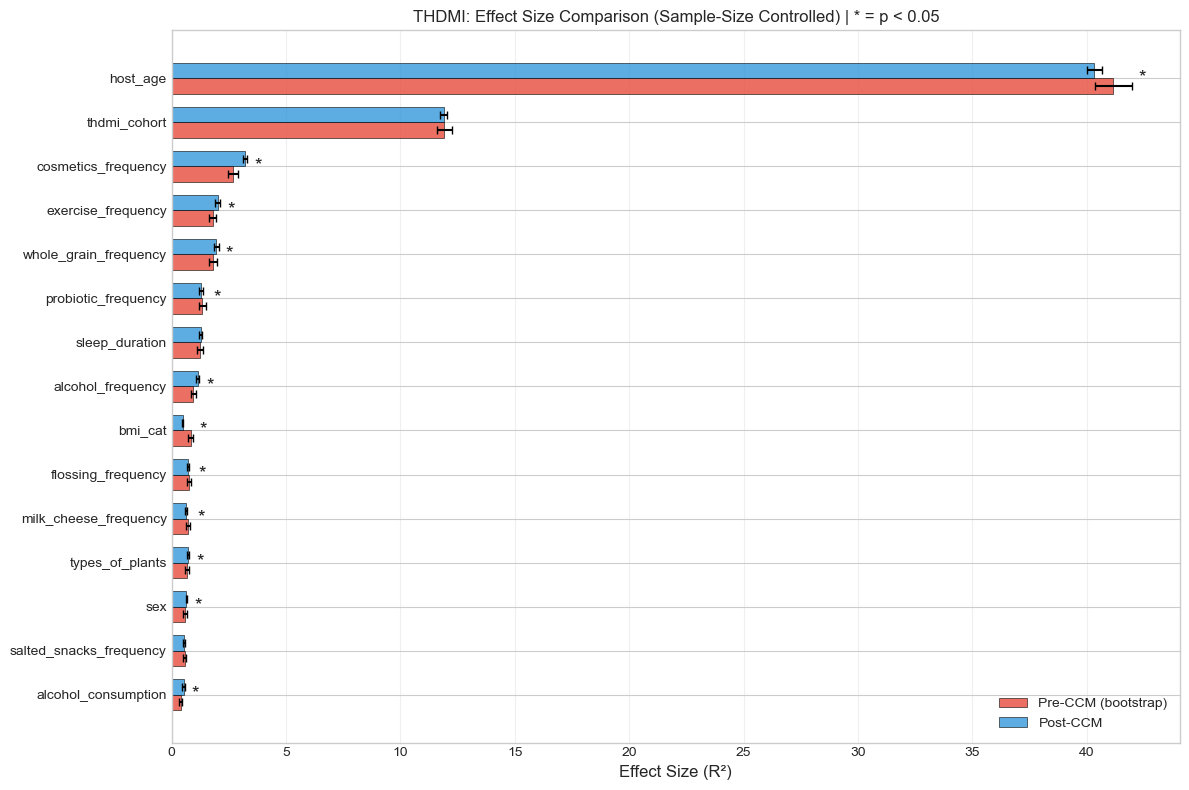

In [21]:
def plot_effect_size_comparison_controlled(comparison_df, dataset_name, n_top=15, output_path=None):
    """Bar chart with error bars for fair comparison."""
    plot_data = comparison_df.sort_values('pre_mean', ascending=True).tail(n_top)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    y_pos = np.arange(len(plot_data))
    height = 0.35
    
    bars1 = ax.barh(y_pos - height/2, plot_data['pre_mean'], height, 
                    xerr=plot_data['pre_std'], capsize=3,
                    label='Pre-CCM (bootstrap)', color='#e74c3c', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    bars2 = ax.barh(y_pos + height/2, plot_data['post_mean'], height,
                    xerr=plot_data['post_std'], capsize=3,
                    label='Post-CCM', color='#3498db', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    for i, (_, row) in enumerate(plot_data.iterrows()):
        if row['significant']:
            max_val = max(row['pre_mean'] + row['pre_std'], row['post_mean'] + row['post_std'])
            ax.text(max_val + 0.3, y_pos[i], '*', fontsize=14, ha='left', va='center')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['category'], fontsize=10)
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_title(f'{dataset_name}: Effect Size Comparison (Sample-Size Controlled) | * = p < 0.05',
                 fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {output_path}")
    
    plt.show()
    return fig

fig1 = plot_effect_size_comparison_controlled(
    comparison_df,
    DATASET_NAME,
    n_top=15,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_effect_size_controlled.png')
)

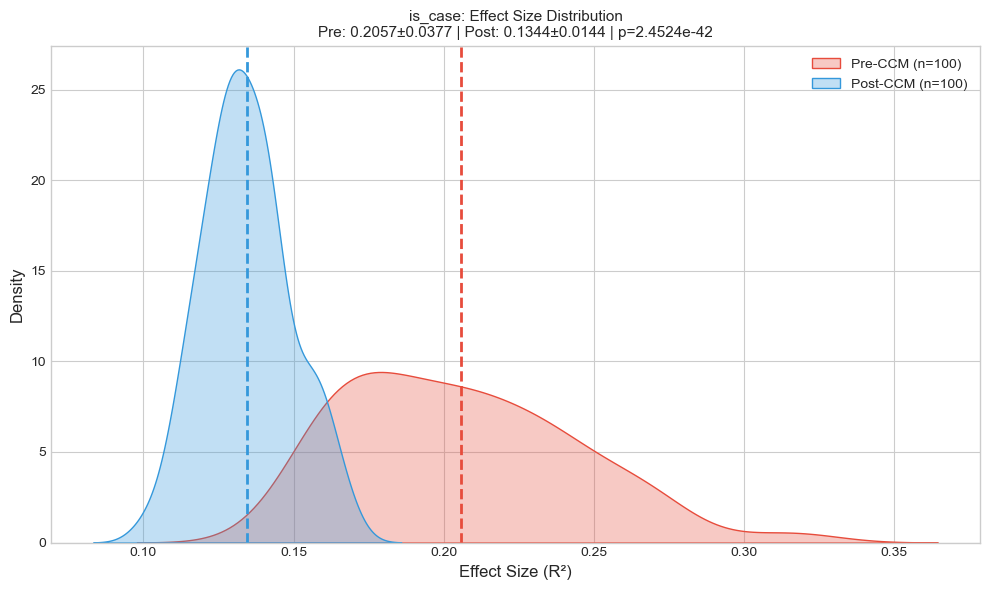

In [22]:
def plot_distribution_comparison(pre_all_df, post_all_df, category, output_path=None):
    """Overlapping distributions for a category."""
    pre_vals = pre_all_df[pre_all_df['category'] == category]['r_squared'].values
    post_vals = post_all_df[post_all_df['category'] == category]['r_squared'].values
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.kdeplot(pre_vals, ax=ax, color='#e74c3c', fill=True, alpha=0.3, 
                label=f'Pre-CCM (n={len(pre_vals)})')
    sns.kdeplot(post_vals, ax=ax, color='#3498db', fill=True, alpha=0.3,
                label=f'Post-CCM (n={len(post_vals)})')
    
    ax.axvline(pre_vals.mean(), color='#e74c3c', linestyle='--', linewidth=2)
    ax.axvline(post_vals.mean(), color='#3498db', linestyle='--', linewidth=2)
    
    t_stat, p_val = stats.ttest_ind(pre_vals, post_vals)
    
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{category}: Effect Size Distribution\n'
                 f'Pre: {pre_vals.mean():.4f}±{pre_vals.std():.4f} | '
                 f'Post: {post_vals.mean():.4f}±{post_vals.std():.4f} | '
                 f'p={p_val:.4e}', fontsize=11)
    ax.legend()
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()
    return fig

# Case-control distribution
fig2 = plot_distribution_comparison(
    cc_pre_all, cc_post_all, 'is_case',
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_case_control_dist.png')
)

Saved: thdmi_ccm_analysis_controlled/THDMI_scatter_controlled.png


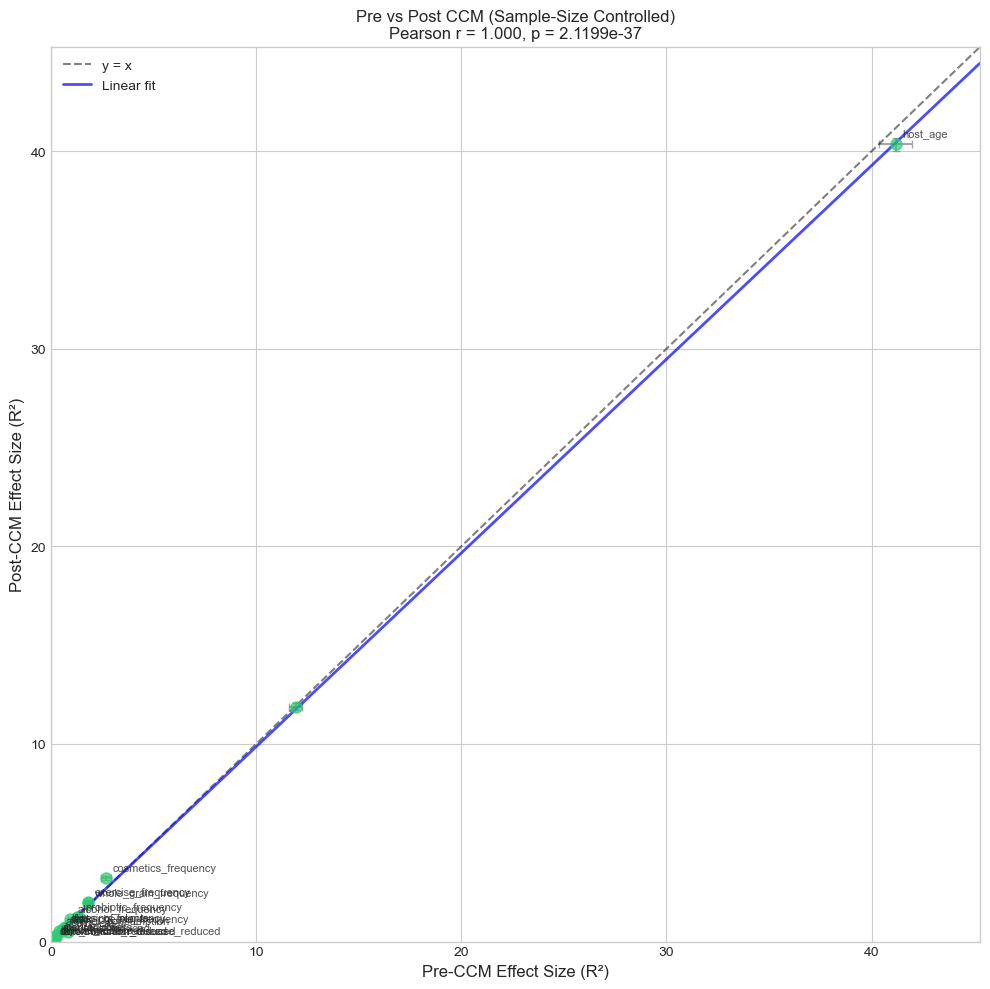

In [23]:
def plot_scatter_with_errorbars(comparison_df, output_path=None):
    """Scatter plot with error bars."""
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.errorbar(comparison_df['pre_mean'], comparison_df['post_mean'],
                xerr=comparison_df['pre_std'], yerr=comparison_df['post_std'],
                fmt='o', markersize=8, capsize=3, alpha=0.7,
                color='#2ecc71', ecolor='gray')
    
    max_val = max(comparison_df['pre_mean'].max(), comparison_df['post_mean'].max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y = x')
    
    z = np.polyfit(comparison_df['pre_mean'], comparison_df['post_mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, max_val, 100)
    ax.plot(x_line, p(x_line), 'b-', alpha=0.7, linewidth=2, label='Linear fit')
    
    for _, row in comparison_df.iterrows():
        if row['significant']:
            ax.annotate(row['category'], 
                       (row['pre_mean'], row['post_mean']),
                       fontsize=8, alpha=0.8,
                       xytext=(5, 5), textcoords='offset points')
    
    corr, p_corr = stats.pearsonr(comparison_df['pre_mean'], comparison_df['post_mean'])
    
    ax.set_xlabel('Pre-CCM Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Post-CCM Effect Size (R²)', fontsize=12)
    ax.set_title(f'Pre vs Post CCM (Sample-Size Controlled)\n'
                 f'Pearson r = {corr:.3f}, p = {p_corr:.4e}', fontsize=12)
    ax.legend(loc='upper left')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved: {output_path}")
    
    plt.show()
    return fig

fig3 = plot_scatter_with_errorbars(
    comparison_df,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_scatter_controlled.png')
)

## 14. Summary

In [24]:
print("\n" + "="*70)
print(f"SUMMARY: {DATASET_NAME} Effect Size Analysis (SAMPLE-SIZE CONTROLLED)")
print("="*70)

print(f"\nDataset: {DATASET_NAME}")
print(f"Distance Metric: {DISTANCE_METRIC}")
print(f"Matching Categories: {MATCHING_CATEGORIES}")
print(f"Numeric Categories: {NUMERIC_CATEGORIES} (tolerance: {TOLERANCE_MAP})")

print(f"\n--- Original Sample Sizes ---")
print(f"Cases: {len(focus)}, Controls: {len(background)}")
print(f"Ratio (case:control): {len(focus)/len(background):.2f}:1")

print(f"\n--- Analysis Sample Sizes (Controlled) ---")
print(f"{TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")
print(f"Bootstrap iterations: {N_BOOTSTRAP}")
print(f"CCM iterations: {N_ITERATIONS}")

print(f"\n--- Case-Control Effect Size ---")
print(f"Pre-CCM:  R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM: R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

delta = cc_post_all['r_squared'].mean() - cc_pre_all['r_squared'].mean()
pct = delta / cc_pre_all['r_squared'].mean() * 100 if cc_pre_all['r_squared'].mean() > 0 else 0
t_stat, p_val = stats.ttest_ind(cc_pre_all['r_squared'].values, cc_post_all['r_squared'].values)

print(f"Change: {delta:+.4f} ({pct:+.1f}%)")
print(f"p-value: {p_val:.4e}")

print(f"\n--- Interpretation ---")
if p_val < 0.05:
    if delta > 0:
        print("✓ Case-control effect INCREASED after CCM")
        print("  → Disease signal is stronger after controlling confounders")
    else:
        print("⚠ Case-control effect DECREASED after CCM")
        print("  → Some original effect was due to confounding")
        print(f"  → Remaining {cc_post_all['r_squared'].mean():.4f} is 'true' signal")
else:
    print("○ No significant difference after CCM")
    print("  → Original effect was robust (not due to confounders)")

print(f"\n--- Confounders with Significant Changes ---")
sig_changes = comparison_df[comparison_df['significant']].sort_values('delta')
for _, row in sig_changes.head(10).iterrows():
    direction = '↓' if row['delta'] < 0 else '↑'
    print(f"  {row['category']}: {row['pre_mean']:.4f} → {row['post_mean']:.4f} ({row['pct_change']:+.1f}%) {direction}")


SUMMARY: THDMI Effect Size Analysis (SAMPLE-SIZE CONTROLLED)

Dataset: THDMI
Distance Metric: Unweighted UniFrac
Matching Categories: ['sex', 'thdmi_cohort', 'bmi_cat', 'cosmetics_frequency']
Numeric Categories: ['host_age'] (tolerance: {'host_age': 5})

--- Original Sample Sizes ---
Cases: 1058, Controls: 918
Ratio (case:control): 1.15:1

--- Analysis Sample Sizes (Controlled) ---
563 cases + 563 controls = 1126 total
Bootstrap iterations: 100
CCM iterations: 100

--- Case-Control Effect Size ---
Pre-CCM:  R² = 0.2057 ± 0.0379
Post-CCM: R² = 0.1344 ± 0.0145
Change: -0.0713 (-34.7%)
p-value: 2.4524e-42

--- Interpretation ---
⚠ Case-control effect DECREASED after CCM
  → Some original effect was due to confounding
  → Remaining 0.1344 is 'true' signal

--- Confounders with Significant Changes ---
  host_age: 41.1642 → 40.3406 (-2.0%) ↓
  bmi_cat: 0.8213 → 0.4896 (-40.4%) ↓
  milk_cheese_frequency: 0.7130 → 0.6256 (-12.3%) ↓
  probiotic_frequency: 1.3444 → 1.2582 (-6.4%) ↓
  autoimmune

In [25]:
# Export results
comparison_df.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_comparison_controlled.csv'), index=False)
effect_sizes_pre.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_pre_bootstrap.csv'), index=False)
effect_sizes_post.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_post_ccm.csv'), index=False)
cc_pre_all.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_cc_pre_all.csv'), index=False)
cc_post_all.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_cc_post_all.csv'), index=False)

print(f"\nResults exported to {OUTPUT_DIR}/")


Results exported to thdmi_ccm_analysis_controlled/


## 15. Why THDMI is Different from AGP

### The Balanced Design:
- **1,058 cases vs 918 controls** = 1.15:1 ratio (nearly balanced)
- Compare to AGP: 169 cases vs 4672 controls = 1:27.6 (extreme imbalance)

### Implications:
1. **Less sample-size bias**: Pre-CCM effect sizes aren't artificially inflated
2. **True confounding detection**: Changes in effect sizes reflect actual confounding
3. **Different CCM goals**: CCM here controls confounders, not sample size imbalance

### What to Expect:
- Smaller pre/post differences compared to AGP (because AGP's differences were partly due to sample size)
- More interpretable changes: if effect sizes change, it's due to actual confounding
- The `unhealthy` signal may remain stable or change based on how well demographics/lifestyle correlate with health status